In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from itertools import permutations
import time

%matplotlib inline

PROJECT_ROOT = Path(r"C:\Users\pande\OneDrive\Documents\Waste management grid")
PROCESSED = PROJECT_ROOT / "data" / "processed"

# District clusters (has BoroCd + land_use_category + predicted_tons)
district_summary = pd.read_parquet(PROCESSED / "district_clusters.parquet")
districts_gdf = gpd.read_file(PROCESSED / "districts.geojson")

# Get centroids in lat/lon (same projection approach as Notebook 02)
districts_proj = districts_gdf.to_crs(epsg=2263)
centroids = districts_proj.geometry.centroid.to_crs(epsg=4326)
districts_gdf["centroid_lat"] = centroids.y
districts_gdf["centroid_lon"] = centroids.x

# Merge centroids with cluster/waste info — only the 59 districts with real data
nodes = district_summary.merge(
    districts_gdf[["BoroCd", "centroid_lat", "centroid_lon"]], on="BoroCd", how="left"
)

print(nodes.shape)  # should be (59, ...)
nodes[["BoroCd", "centroid_lat", "centroid_lon", "predicted_tons", "land_use_category"]].head()

C:\Users\pande\anaconda3\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


(59, 13)


,BoroCd,centroid_lat,centroid_lon,predicted_tons,land_use_category
0,101,40.707380,-74.011997,2166.203745,Institutional
1,102,40.729841,-74.001559,3017.161189,Residential
2,103,40.719596,-73.985541,6928.256381,Commercial
3,104,40.755422,-73.997537,4520.761040,Residential
4,105,40.752276,-73.984057,2184.697388,Residential


In [3]:
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/lon points."""
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

n = len(nodes)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            dist_matrix[i, j] = haversine(
                nodes.iloc[i]["centroid_lat"], nodes.iloc[i]["centroid_lon"],
                nodes.iloc[j]["centroid_lat"], nodes.iloc[j]["centroid_lon"]
            )

print("Distance matrix shape:", dist_matrix.shape)
print("Avg inter-district distance (km):", dist_matrix[dist_matrix > 0].mean().round(2))
print("Max distance (km):", dist_matrix.max().round(2))

Distance matrix shape: (59, 59)
Avg inter-district distance (km): 14.92
Max distance (km): 47.83


In [4]:
def nearest_neighbor_route(dist_matrix, start=0):
    n = len(dist_matrix)
    visited = [start]
    unvisited = set(range(n)) - {start}
    
    total_distance = 0
    current = start
    
    while unvisited:
        nearest = min(unvisited, key=lambda j: dist_matrix[current][j])
        total_distance += dist_matrix[current][nearest]
        visited.append(nearest)
        unvisited.remove(nearest)
        current = nearest
    
    # Return to start (closed tour — a real truck route returns to depot)
    total_distance += dist_matrix[current][start]
    visited.append(start)
    
    return visited, total_distance

start_time = time.time()
nn_route, nn_distance = nearest_neighbor_route(dist_matrix, start=0)
nn_runtime = time.time() - start_time

print(f"Nearest Neighbor route distance: {nn_distance:.2f} km")
print(f"Runtime: {nn_runtime:.5f} sec")
print(f"Route (by index): {nn_route}")

Nearest Neighbor route distance: 238.86 km
Runtime: 0.00066 sec
Route (by index): [0, 2, 1, 5, 4, 3, 7, 6, 10, 9, 8, 12, 13, 14, 15, 16, 11, 17, 18, 19, 23, 22, 21, 20, 48, 52, 49, 53, 54, 50, 51, 28, 39, 40, 32, 31, 26, 27, 46, 47, 45, 44, 42, 43, 24, 25, 29, 30, 35, 37, 41, 38, 36, 34, 33, 56, 57, 58, 55, 0]


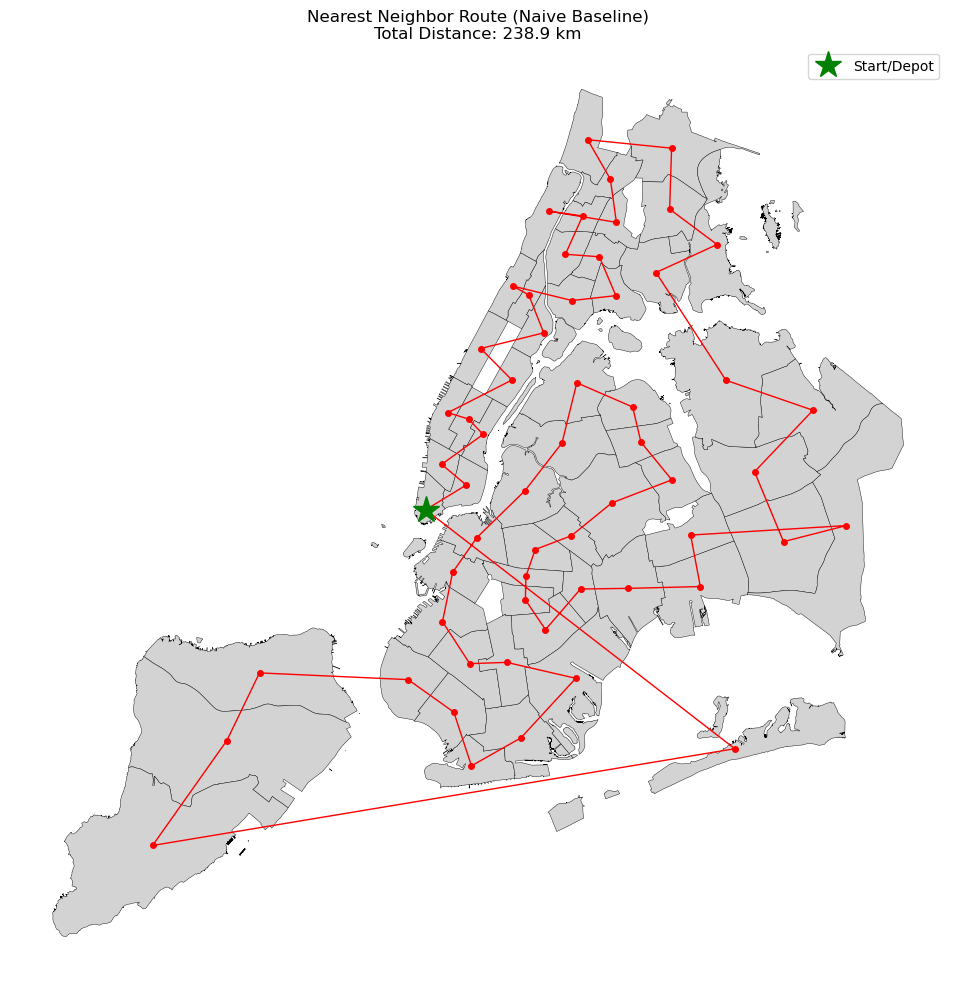

In [5]:
route_coords = nodes.iloc[nn_route][["centroid_lon", "centroid_lat"]].values

fig, ax = plt.subplots(figsize=(10, 10))
merged = districts_gdf.merge(district_summary, on="BoroCd")
merged.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.3)

ax.plot(route_coords[:, 0], route_coords[:, 1], "r-o", markersize=4, linewidth=1)
ax.plot(route_coords[0, 0], route_coords[0, 1], "g*", markersize=20, label="Start/Depot")

ax.set_title(f"Nearest Neighbor Route (Naive Baseline)\nTotal Distance: {nn_distance:.1f} km")
ax.legend()
ax.axis("off")
plt.tight_layout()
plt.savefig(PROCESSED / "route_nearest_neighbor.png", dpi=150)
plt.show()

In [6]:
def held_karp(dist_matrix):
    """Exact TSP via dynamic programming. Returns (optimal_distance, optimal_path)."""
    n = len(dist_matrix)
    C = {}

    # Base case: paths from node 0 to each other node
    for k in range(1, n):
        C[(1 << k, k)] = (dist_matrix[0][k], 0)

    # Iterate over subsets of increasing size
    for subset_size in range(2, n):
        for subset in permutations(range(1, n), subset_size):
            subset = frozenset(subset)
            bits = 0
            for bit in subset:
                bits |= 1 << bit

            for k in subset:
                prev_bits = bits & ~(1 << k)
                res = []
                for m in subset:
                    if m == k:
                        continue
                    if (prev_bits, m) in C:
                        res.append((C[(prev_bits, m)][0] + dist_matrix[m][k], m))
                if res:
                    C[(bits, k)] = min(res)

    # Close the tour back to node 0
    bits = (2**n - 1) - 1
    res = []
    for k in range(1, n):
        if (bits, k) in C:
            res.append((C[(bits, k)][0] + dist_matrix[k][0], k))
    opt_distance, parent = min(res)

    # Reconstruct path
    path = [0]
    bits_track = bits
    last = parent
    for _ in range(n - 1):
        path.append(last)
        new_bits = bits_track & ~(1 << last)
        _, last = C[(bits_track, last)]
        bits_track = new_bits
    path.append(0)

    return opt_distance, path[::-1] if path[-1] == 0 else path


# Select top-N highest predicted-waste districts as our small subset
N_SUBSET = 10  # keep small — 12+ gets slow, this is meant to demo exponential blowup
top_hotspots = nodes.sort_values("predicted_tons", ascending=False).head(N_SUBSET).reset_index(drop=True)

# Build a small distance matrix just for this subset
small_dist = np.zeros((N_SUBSET, N_SUBSET))
for i in range(N_SUBSET):
    for j in range(N_SUBSET):
        if i != j:
            small_dist[i, j] = haversine(
                top_hotspots.iloc[i]["centroid_lat"], top_hotspots.iloc[i]["centroid_lon"],
                top_hotspots.iloc[j]["centroid_lat"], top_hotspots.iloc[j]["centroid_lon"]
            )

start_time = time.time()
hk_distance, hk_path = held_karp(small_dist)
hk_runtime = time.time() - start_time

print(f"Held-Karp EXACT optimal distance ({N_SUBSET} top hotspot districts): {hk_distance:.2f} km")
print(f"Runtime: {hk_runtime:.4f} sec")
print(f"Optimal path (by subset index): {hk_path}")

Held-Karp EXACT optimal distance (10 top hotspot districts): 101.96 km
Runtime: 45.4575 sec
Optimal path (by subset index): [0, 5, 2, 9, 7, 1, 4, 6, 8, 3, 0]


n=4: 0.0002 sec
n=5: 0.0004 sec
n=6: 0.0030 sec
n=7: 0.0407 sec
n=8: 0.3326 sec
n=9: 3.6450 sec
n=10: 54.6298 sec


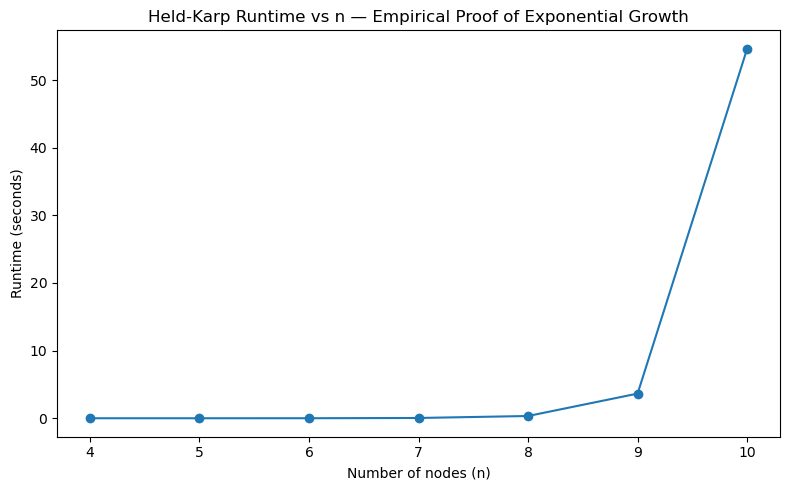

In [7]:
runtimes = []
sizes = list(range(4, N_SUBSET + 1))

for size in sizes:
    sub_nodes = nodes.sort_values("predicted_tons", ascending=False).head(size).reset_index(drop=True)
    sub_dist = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if i != j:
                sub_dist[i, j] = haversine(
                    sub_nodes.iloc[i]["centroid_lat"], sub_nodes.iloc[i]["centroid_lon"],
                    sub_nodes.iloc[j]["centroid_lat"], sub_nodes.iloc[j]["centroid_lon"]
                )
    t0 = time.time()
    held_karp(sub_dist)
    runtimes.append(time.time() - t0)
    print(f"n={size}: {runtimes[-1]:.4f} sec")

plt.figure(figsize=(8, 5))
plt.plot(sizes, runtimes, marker="o")
plt.xlabel("Number of nodes (n)")
plt.ylabel("Runtime (seconds)")
plt.title("Held-Karp Runtime vs n — Empirical Proof of Exponential Growth")
plt.tight_layout()
plt.savefig(PROCESSED / "heldkarp_runtime_growth.png", dpi=150)
plt.show()

In [8]:
import random

def route_distance(route, dist_matrix):
    """Total distance of a closed tour."""
    return sum(dist_matrix[route[i]][route[i+1]] for i in range(len(route)-1)) + dist_matrix[route[-1]][route[0]]

def create_individual(n):
    """A random permutation of district indices (excluding depot, which we fix at start)."""
    individual = list(range(1, n))
    random.shuffle(individual)
    return [0] + individual  # depot fixed as start

def initial_population(pop_size, n):
    return [create_individual(n) for _ in range(pop_size)]

def tournament_selection(population, fitnesses, k=5):
    """Pick the best of k random individuals."""
    selected = random.sample(list(zip(population, fitnesses)), k)
    selected.sort(key=lambda x: x[1])
    return selected[0][0]

def ordered_crossover(parent1, parent2):
    """OX crossover — preserves relative order, keeps depot fixed at position 0."""
    n = len(parent1)
    start, end = sorted(random.sample(range(1, n), 2))
    
    child = [None] * n
    child[0] = 0
    child[start:end] = parent1[start:end]
    
    fill_values = [gene for gene in parent2 if gene not in child]
    fill_idx = 0
    for i in range(1, n):
        if child[i] is None:
            child[i] = fill_values[fill_idx]
            fill_idx += 1
    return child

def swap_mutation(individual, mutation_rate=0.02):
    """Randomly swap two cities (never touches depot at index 0)."""
    individual = individual.copy()
    for i in range(1, len(individual)):
        if random.random() < mutation_rate:
            j = random.randint(1, len(individual) - 1)
            individual[i], individual[j] = individual[j], individual[i]
    return individual

In [9]:
def two_opt(route, dist_matrix):
    """Local search: repeatedly reverse segments if it shortens the tour. Depot fixed at index 0."""
    best = route[:]
    improved = True
    while improved:
        improved = False
        for i in range(1, len(best) - 1):
            for j in range(i + 1, len(best)):
                if j - i == 1:
                    continue
                new_route = best[:i] + best[i:j][::-1] + best[j:]
                if route_distance(new_route, dist_matrix) < route_distance(best, dist_matrix):
                    best = new_route
                    improved = True
    return best


def genetic_algorithm_v2(dist_matrix, nn_seed, pop_size=200, generations=500, mutation_rate=0.02, elite_size=10):
    n = len(dist_matrix)
    
    # Seed population: NN route + mutated variants of it + random individuals
    population = [nn_seed]
    for _ in range(pop_size // 4):
        population.append(swap_mutation(nn_seed, mutation_rate=0.1))
    while len(population) < pop_size:
        population.append(create_individual(n))
    
    best_distance_history = []

    for gen in range(generations):
        fitnesses = [route_distance(ind, dist_matrix) for ind in population]
        best_idx = fitnesses.index(min(fitnesses))
        best_distance_history.append(fitnesses[best_idx])

        sorted_pop = [ind for _, ind in sorted(zip(fitnesses, population), key=lambda x: x[0])]
        new_population = sorted_pop[:elite_size]

        while len(new_population) < pop_size:
            parent1 = tournament_selection(population, fitnesses)
            parent2 = tournament_selection(population, fitnesses)
            child = ordered_crossover(parent1, parent2)
            child = swap_mutation(child, mutation_rate)
            new_population.append(child)

        population = new_population

    final_fitnesses = [route_distance(ind, dist_matrix) for ind in population]
    best_idx = final_fitnesses.index(min(final_fitnesses))
    best_route = population[best_idx]
    
    # Polish with 2-opt
    best_route_refined = two_opt(best_route, dist_matrix)
    
    return best_route_refined, route_distance(best_route_refined, dist_matrix), best_distance_history


random.seed(42)
start_time = time.time()
ga_route, ga_distance, ga_history = genetic_algorithm_v2(dist_matrix, nn_seed=nn_route[:-1], pop_size=200, generations=500)
ga_runtime = time.time() - start_time

print(f"Genetic Algorithm (+2-opt refinement) route distance: {ga_distance:.2f} km")
print(f"Runtime: {ga_runtime:.2f} sec")
print(f"Improvement over Nearest Neighbor: {(nn_distance - ga_distance) / nn_distance * 100:.1f}%")

Genetic Algorithm (+2-opt refinement) route distance: 218.55 km
Runtime: 11.15 sec
Improvement over Nearest Neighbor: 8.5%


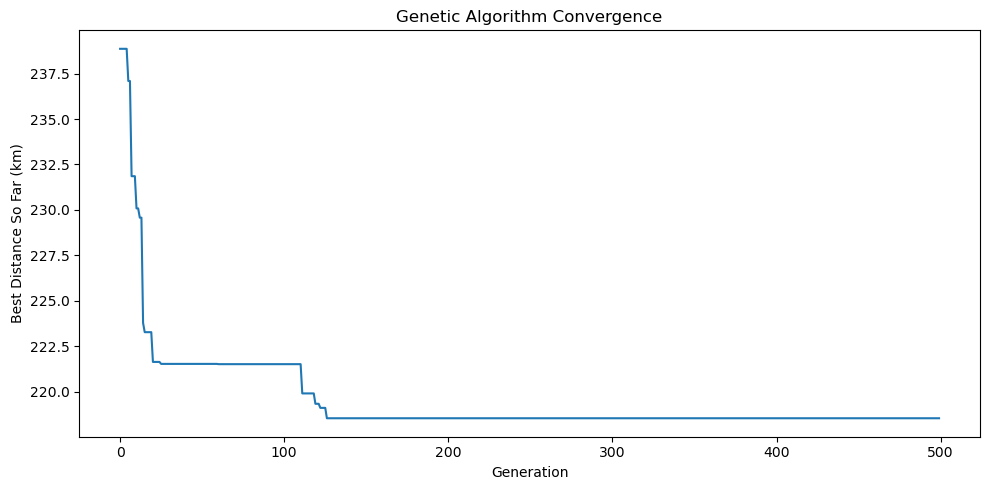

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(ga_history)
plt.xlabel("Generation")
plt.ylabel("Best Distance So Far (km)")
plt.title("Genetic Algorithm Convergence")
plt.tight_layout()
plt.savefig(PROCESSED / "ga_convergence.png", dpi=150)
plt.show()

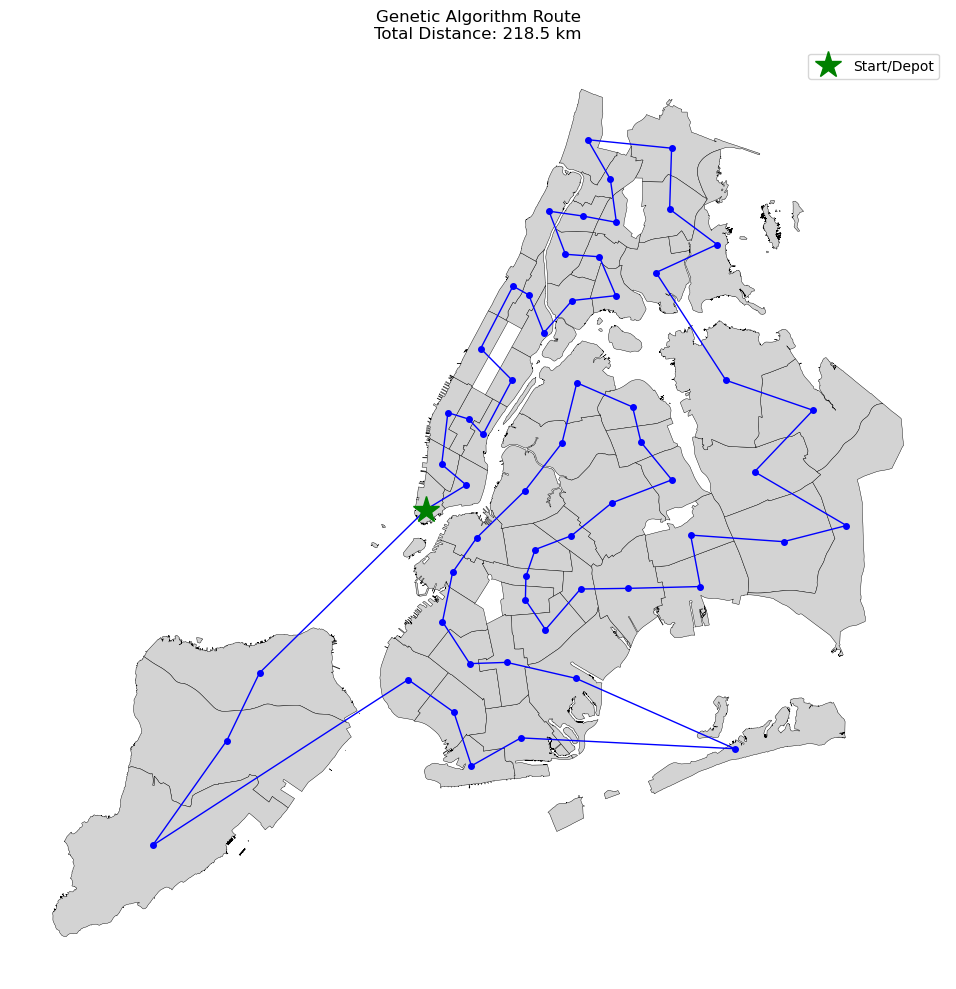

In [11]:
route_coords_ga = nodes.iloc[ga_route + [ga_route[0]]][["centroid_lon", "centroid_lat"]].values

fig, ax = plt.subplots(figsize=(10, 10))
merged.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.3)
ax.plot(route_coords_ga[:, 0], route_coords_ga[:, 1], "b-o", markersize=4, linewidth=1)
ax.plot(route_coords_ga[0, 0], route_coords_ga[0, 1], "g*", markersize=20, label="Start/Depot")
ax.set_title(f"Genetic Algorithm Route\nTotal Distance: {ga_distance:.1f} km")
ax.legend()
ax.axis("off")
plt.tight_layout()
plt.savefig(PROCESSED / "route_genetic_algorithm.png", dpi=150)
plt.show()

In [12]:
comparison = pd.DataFrame({
    "Algorithm": ["Nearest Neighbor (Naive)", "Genetic Algorithm + 2-opt", "Held-Karp (Exact, n=10 subset)"],
    "Scope": ["All 59 districts", "All 59 districts", "Top 10 hotspot districts only"],
    "Total Distance (km)": [nn_distance, ga_distance, hk_distance],
    "Runtime (sec)": [nn_runtime, ga_runtime, hk_runtime],
    "Time Complexity": ["O(n²)", "O(pop × gen × n)", "O(n² × 2ⁿ)"],
})

# Estimate travel time and fuel (state your assumptions clearly)
AVG_SPEED_KMH = 25       # typical urban collection truck speed
FUEL_RATE_L_PER_KM = 0.4  # approx. for a waste collection truck

comparison["Est. Travel Time (hrs)"] = comparison["Total Distance (km)"] / AVG_SPEED_KMH
comparison["Est. Fuel (Liters)"] = comparison["Total Distance (km)"] * FUEL_RATE_L_PER_KM

comparison

,Algorithm,Scope,Total Distance (km),Runtime (sec),Time Complexity,Est. Travel Time (hrs),Est. Fuel (Liters)
0,Nearest Neighbor (Naive),All 59 districts,238.861604,0.000662,O(n²),9.554464,95.544641
1,Genetic Algorithm + 2-opt,All 59 districts,218.546872,11.148769,O(pop × gen × n),8.741875,87.418749
2,"Held-Karp (Exact, n=10 subset)",Top 10 hotspot districts only,101.962009,45.457457,O(n² × 2ⁿ),4.078480,40.784804


In [13]:
pct_improvement = (nn_distance - ga_distance) / nn_distance * 100
fuel_saved = (nn_distance - ga_distance) * FUEL_RATE_L_PER_KM
time_saved = (nn_distance - ga_distance) / AVG_SPEED_KMH

print(f"GA+2-opt vs Naive NN:")
print(f"  Distance saved: {nn_distance - ga_distance:.2f} km ({pct_improvement:.1f}%)")
print(f"  Estimated fuel saved: {fuel_saved:.2f} liters per collection run")
print(f"  Estimated time saved: {time_saved:.2f} hours per collection run")
print(f"\nHeld-Karp optimal (n=10 subset) confirms GA is finding genuinely good solutions,")
print(f"though direct comparison is only valid on the same {len(top_hotspots)}-node subset, not the full 59-node problem.")

GA+2-opt vs Naive NN:
  Distance saved: 20.31 km (8.5%)
  Estimated fuel saved: 8.13 liters per collection run
  Estimated time saved: 0.81 hours per collection run

Held-Karp optimal (n=10 subset) confirms GA is finding genuinely good solutions,
though direct comparison is only valid on the same 10-node subset, not the full 59-node problem.


In [14]:
comparison.to_csv(PROCESSED / "route_comparison.csv", index=False)
print("Saved route_comparison.csv")

Saved route_comparison.csv
